# Isotope Distribution Modeling

Interactive visualization of isotope distributions for peptides and proteins.

The isotope distribution calculation is based on the Kubinyi algorithm
(Kubinyi, *Analytica Chimica Acta*, 247, 1991, 107-119) with natural isotope
abundances from D.E. Matthews as implemented in
[IDCalc](https://github.com/maccoss/IDCalc).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

import isotope_calc as ic

## Interactive Isotope Distribution Explorer

Enter a peptide sequence (e.g., `MYFAVRITEPEPTIDE`) or an elemental formula
(e.g., `C60H86N16O15`). Adjust the charge state, resolving power, and display
mode to explore how isotope distributions appear under different instrument
conditions.

In [2]:
def plot_isotope_distribution(input_text, charge, resolving_power,
                              instrument, mz_ref,
                              display_mode, show_mono, show_avg,
                              x_low, x_high):
    """Plot the isotope distribution for a single molecule."""
    composition = ic.parse_input(input_text)
    formula = ic.composition_to_formula(composition)
    dist = ic.calculate_isotope_distribution(composition)
    mono = ic.monoisotopic_mass(composition)
    avg = ic.average_mass(composition, dist)
    mz = ic.mz_values(mono, len(dist), charge)

    # Map instrument display name to internal key
    inst_key = ic.INSTRUMENT_TYPES[instrument]

    fig, ax = plt.subplots(figsize=(12, 6))

    if display_mode in ("Profile", "Both"):
        x, y = ic.generate_profile(mz, dist * 100, resolving_power,
                                   instrument=inst_key, mz_ref=mz_ref)
        ax.plot(x, y, "k-", linewidth=1.5, label="Profile")

    if display_mode in ("Centroids", "Both"):
        markerline, stemlines, baseline = ax.stem(
            mz, dist * 100, linefmt="b-", markerfmt="bo", basefmt="k-"
        )
        plt.setp(stemlines, linewidth=1.5)
        plt.setp(markerline, markersize=4)
        plt.setp(baseline, visible=False)

    # Monoisotopic and average mass markers
    mono_mz = (mono + charge * ic.PROTON_MASS) / charge
    avg_mz = (avg + charge * ic.PROTON_MASS) / charge

    if show_mono:
        ax.axvline(mono_mz, color="green", linestyle="--", alpha=0.8, linewidth=1.5)
        ax.annotate("Monoisotopic", xy=(mono_mz, 100), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=10,
                    color="green", fontweight="bold")

    if show_avg:
        ax.axvline(avg_mz, color="red", linestyle="--", alpha=0.8, linewidth=1.5)
        ax.annotate("Average", xy=(avg_mz, 100), xytext=(0, -14),
                    textcoords="offset points", ha="center", fontsize=10,
                    color="red", fontweight="bold")

    ax.set_xlim(x_low, x_high)

    # Show effective R at the monoisotopic m/z
    eff_rp = ic.effective_resolving_power(mono_mz, inst_key, resolving_power, mz_ref)
    charge_label = f"z = {charge}" if charge > 1 else "z = 1 (neutral + H)"
    ax.set_title(
        f"{formula}    Neutral mass: {mono:.4f} Da    [{charge_label}]\n"
        f"{instrument}    R = {resolving_power:,.0f} @ m/z {mz_ref:.0f}"
        f"    (effective R = {eff_rp:,.0f} @ m/z {mono_mz:.1f})",
        fontsize=12)
    ax.set_xlabel("m/z", fontsize=12)
    ax.set_ylabel("Relative Abundance", fontsize=12)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Monoisotopic m/z: {mono_mz:.4f}    Average m/z: {avg_mz:.4f}")


def create_interactive_explorer():
    """Create the interactive isotope distribution explorer."""
    input_widget = widgets.Text(
        value="MYFAVRITEPEPTIDE",
        description="Input:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="400px"),
    )
    charge_widget = widgets.IntSlider(
        value=1, min=1, max=10, step=1,
        description="Charge state:",
        style={"description_width": "initial"},
    )
    instrument_widget = widgets.Dropdown(
        options=list(ic.INSTRUMENT_TYPES.keys()),
        value="Orbitrap",
        description="Instrument:",
        style={"description_width": "initial"},
    )
    rp_widget = widgets.FloatLogSlider(
        value=30000, base=10, min=2, max=6, step=0.05,
        description="Resolving power:",
        style={"description_width": "initial"},
        readout_format=".0f",
    )
    mz_ref_widget = widgets.FloatText(
        value=200.0, description="R defined at m/z:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="200px"),
    )
    display_widget = widgets.Dropdown(
        options=["Both", "Centroids", "Profile"],
        value="Both",
        description="Display mode:",
        style={"description_width": "initial"},
    )
    x_low_widget = widgets.FloatText(
        value=1900.0, description="X-axis low:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="180px"),
    )
    x_high_widget = widgets.FloatText(
        value=1925.0, description="X-axis high:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="180px"),
    )
    mono_widget = widgets.Checkbox(value=True, description="Show monoisotopic mass")
    avg_widget = widgets.Checkbox(value=True, description="Show average mass")

    output = widgets.Output()

    def update_xlim_defaults(*args):
        """Reset x-axis defaults when input or charge changes."""
        try:
            composition = ic.parse_input(input_widget.value)
            mono = ic.monoisotopic_mass(composition)
            dist = ic.calculate_isotope_distribution(composition)
            charge = charge_widget.value
            mz = ic.mz_values(mono, len(dist), charge)
            margin = max(3.0, (mz[-1] - mz[0]) * 0.5)
            x_low_widget.value = round(mz[0] - margin, 1)
            x_high_widget.value = round(mz[-1] + margin, 1)
        except Exception:
            pass

    def update(*args):
        with output:
            clear_output(wait=True)
            try:
                plot_isotope_distribution(
                    input_widget.value, charge_widget.value,
                    rp_widget.value, instrument_widget.value,
                    mz_ref_widget.value, display_widget.value,
                    mono_widget.value, avg_widget.value,
                    x_low_widget.value, x_high_widget.value,
                )
            except Exception as e:
                print(f"Error: {e}")

    # When input or charge changes, update x-axis defaults then replot
    for w in [input_widget, charge_widget]:
        w.observe(update_xlim_defaults, names="value")

    for w in [input_widget, charge_widget, rp_widget, instrument_widget,
              mz_ref_widget, display_widget, mono_widget, avg_widget,
              x_low_widget, x_high_widget]:
        w.observe(update, names="value")

    input_box = widgets.VBox([
        widgets.HTML("<b>Molecule:</b>"),
        input_widget,
    ])
    instrument_box = widgets.VBox([
        widgets.HTML("<b>Instrument:</b>"),
        instrument_widget, rp_widget, mz_ref_widget, charge_widget,
    ])
    display_box = widgets.VBox([
        widgets.HTML("<b>Display:</b>"),
        display_widget,
        widgets.HBox([x_low_widget, x_high_widget]),
        mono_widget, avg_widget,
    ])
    controls = widgets.HBox([input_box, instrument_box, display_box])

    update_xlim_defaults()
    return widgets.VBox([controls, output])


interactive_explorer = create_interactive_explorer()
display(interactive_explorer)

## Effect of Resolving Power

The resolving power of a mass spectrometer determines whether individual
isotopic peaks can be distinguished. At low resolving power, the isotope
envelope appears as a single broad peak centered near the average mass.
At high resolving power, individual isotopic peaks are resolved and the
monoisotopic peak can be identified.

The plot below overlays the same isotope distribution at multiple resolving
powers, similar to the classic demonstration from mass spectrometry textbooks.

In [3]:
def plot_multi_resolution(input_text, charge=1,
                          resolving_powers=(500, 1000, 5000),
                          instrument="TOF", mz_ref=200.0,
                          ax=None, show_centroids=True):
    """Overlay isotope profiles at multiple resolving powers.

    Args:
        input_text: Elemental formula or peptide sequence.
        charge: Charge state.
        resolving_powers: Tuple of resolving powers to overlay.
        instrument: Instrument type key ("TOF", "quad", "orbitrap", "fticr").
        mz_ref: Reference m/z for resolving power specification.
        ax: Matplotlib axes to plot on (creates new figure if None).
        show_centroids: Whether to show centroid sticks underneath.
    """
    composition = ic.parse_input(input_text)
    formula = ic.composition_to_formula(composition)
    dist = ic.calculate_isotope_distribution(composition)
    mono = ic.monoisotopic_mass(composition)
    avg = ic.average_mass(composition, dist)
    mz = ic.mz_values(mono, len(dist), charge)

    mono_mz = (mono + charge * ic.PROTON_MASS) / charge
    avg_mz = (avg + charge * ic.PROTON_MASS) / charge

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 7))
        standalone = True
    else:
        standalone = False

    # Plot profiles at each resolving power (thickest line = lowest R)
    linewidths = np.linspace(2.5, 1.0, len(resolving_powers))
    for rp, lw in zip(sorted(resolving_powers), linewidths):
        x, y = ic.generate_profile(mz, dist * 100, rp,
                                   instrument=instrument, mz_ref=mz_ref)
        ax.plot(x, y, linewidth=lw, label=f"R = {rp:,.0f}")

    # Centroid sticks
    if show_centroids:
        markerline, stemlines, baseline = ax.stem(
            mz, dist * 100, linefmt="k-", markerfmt="k.", basefmt="k-"
        )
        plt.setp(stemlines, linewidth=0.8, alpha=0.5)
        plt.setp(markerline, markersize=3)
        plt.setp(baseline, visible=False)

    # Annotate monoisotopic and average mass
    ax.annotate("Monoisotopic\nmass", xy=(mono_mz, 103),
                xytext=(mono_mz, 115), fontsize=9, ha="center",
                fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))

    ax.annotate("Average\nmass", xy=(avg_mz, 103),
                xytext=(avg_mz + (avg_mz - mono_mz) * 0.5, 115),
                fontsize=9, ha="center", fontweight="bold",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))

    ax.set_title(f"{formula}", fontsize=14, color="red", fontweight="bold")
    ax.set_xlabel("m/z", fontsize=12)
    ax.set_ylabel("Relative Abundance", fontsize=12)
    ax.set_ylim(0, 130)
    ax.legend(fontsize=11, loc="upper right")
    ax.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.show()
        print(f"Monoisotopic m/z: {mono_mz:.4f}    Average m/z: {avg_mz:.4f}")

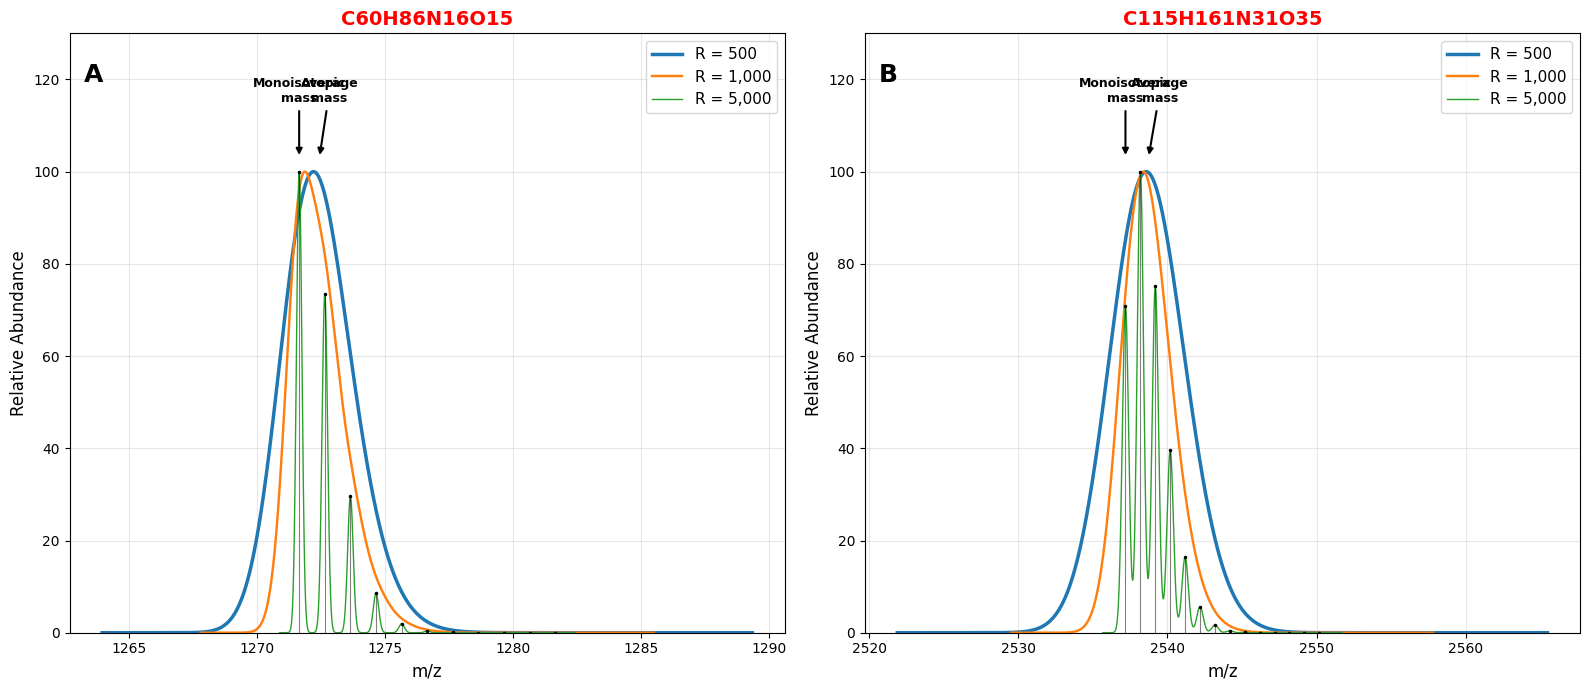

In [4]:
# Side-by-side comparison: small molecule vs larger molecule
# Reproduces the Panel A / Panel B style from lecture slides

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

plot_multi_resolution("C60H86N16O15", charge=1,
                      resolving_powers=(500, 1000, 5000), ax=ax1)

plot_multi_resolution("C115H161N31O35", charge=1,
                      resolving_powers=(500, 1000, 5000), ax=ax2)

ax1.text(0.02, 0.95, "A", transform=ax1.transAxes,
         fontsize=18, fontweight="bold", va="top")
ax2.text(0.02, 0.95, "B", transform=ax2.transAxes,
         fontsize=18, fontweight="bold", va="top")

plt.tight_layout()
plt.show()

## High Resolution vs Low Resolution

At low resolving power (e.g., ion trap, R ~ 500), isotopic peaks merge into a
single broad envelope and the reported m/z is the intensity-weighted centroid
of that envelope. At high resolving power (e.g., Orbitrap, R ~ 50,000),
individual isotopic peaks are fully resolved and each peak's m/z can be
measured independently.

This comparison illustrates why high-resolution instruments provide more
accurate mass measurements.

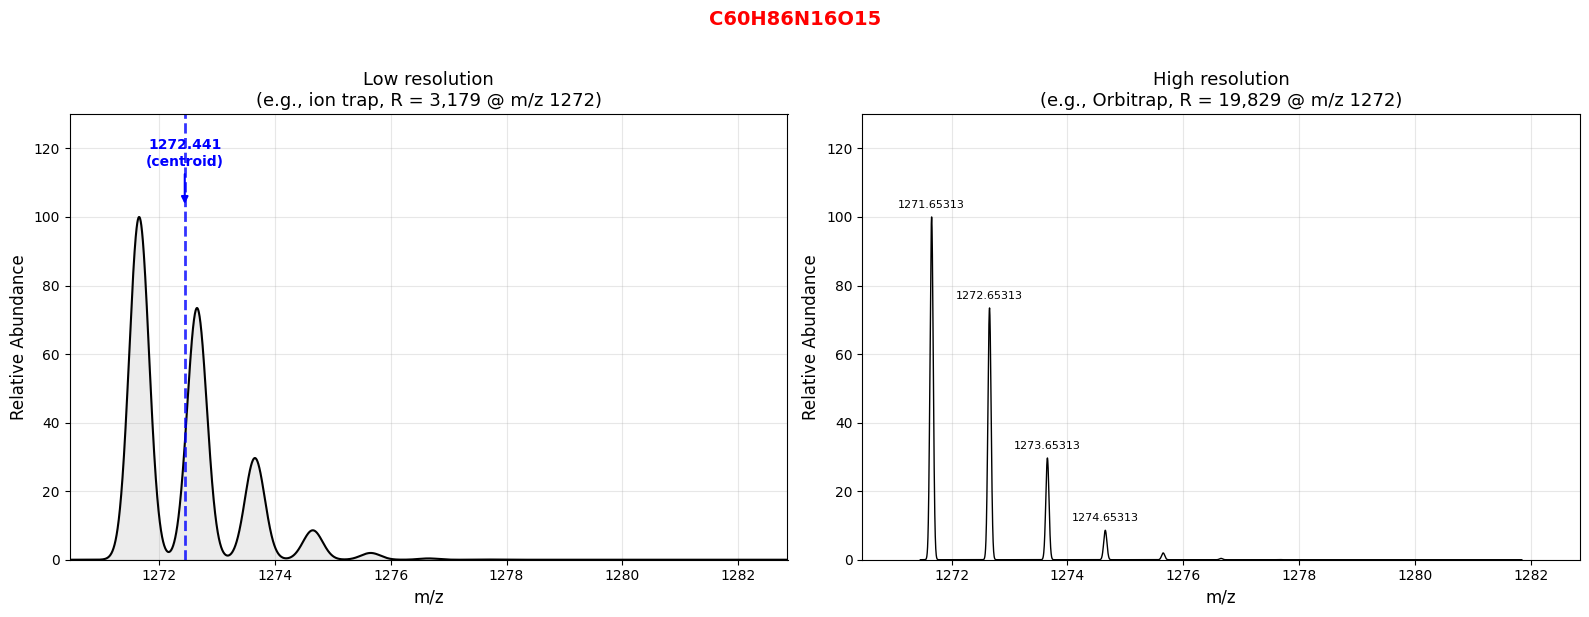

In [5]:
def plot_resolution_comparison(input_text, charge=1,
                               low_rp=500, high_rp=50000,
                               low_instrument="quad", high_instrument="orbitrap",
                               mz_ref=200.0):
    """Side-by-side comparison of low-resolution and high-resolution spectra.

    Args:
        input_text: Elemental formula or peptide sequence.
        charge: Charge state.
        low_rp: Resolving power for the low-resolution panel.
        high_rp: Resolving power for the high-resolution panel.
        low_instrument: Instrument type for low-res panel.
        high_instrument: Instrument type for high-res panel.
        mz_ref: Reference m/z for resolving power specification.
    """
    composition = ic.parse_input(input_text)
    formula = ic.composition_to_formula(composition)
    dist = ic.calculate_isotope_distribution(composition)
    mono = ic.monoisotopic_mass(composition)
    avg = ic.average_mass(composition, dist)
    mz = ic.mz_values(mono, len(dist), charge)

    mono_mz = (mono + charge * ic.PROTON_MASS) / charge
    avg_mz = (avg + charge * ic.PROTON_MASS) / charge

    # Compute profiles
    x_low, y_low = ic.generate_profile(mz, dist * 100, low_rp,
                                       instrument=low_instrument, mz_ref=mz_ref)
    x_high, y_high = ic.generate_profile(mz, dist * 100, high_rp,
                                         instrument=high_instrument, mz_ref=mz_ref)
    # Shared x-axis limits
    xlim = (x_low.min(), x_low.max())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left panel: low resolution (e.g., ion trap)
    ax1.plot(x_low, y_low, "k-", linewidth=1.5)
    ax1.fill_between(x_low, y_low, alpha=0.15, color="gray")

    # Centroid of the low-res envelope
    total = np.sum(y_low)
    if total > 0:
        centroid_mz = np.sum(x_low * y_low) / total
    else:
        centroid_mz = mono_mz
    ax1.axvline(centroid_mz, color="blue", linestyle="--", linewidth=2, alpha=0.8)
    ax1.annotate(f"{centroid_mz:.3f}\n(centroid)", xy=(centroid_mz, 103),
                 xytext=(centroid_mz, 115), fontsize=10, ha="center",
                 fontweight="bold", color="blue",
                 arrowprops=dict(arrowstyle="-|>", color="blue", lw=1.5))

    eff_rp_low = ic.effective_resolving_power(mono_mz, low_instrument, low_rp, mz_ref)
    ax1.set_title(f"Low resolution\n(e.g., ion trap, R = {eff_rp_low:,.0f} @ m/z {mono_mz:.0f})",
                  fontsize=13)
    ax1.set_xlabel("m/z", fontsize=12)
    ax1.set_ylabel("Relative Abundance", fontsize=12)
    ax1.set_xlim(xlim)
    ax1.set_ylim(0, 130)
    ax1.grid(True, alpha=0.3)

    # Right panel: high resolution (e.g., Orbitrap)
    ax2.plot(x_high, y_high, "k-", linewidth=1.0)

    # Label the top few peaks with their m/z values
    top_n = min(5, len(mz))
    top_indices = np.argsort(dist)[-top_n:][::-1]
    for idx in top_indices:
        if dist[idx] > 0.05:
            ax2.annotate(f"{mz[idx]:.5f}", xy=(mz[idx], dist[idx] * 100 + 2),
                         fontsize=8, ha="center", va="bottom")

    eff_rp_high = ic.effective_resolving_power(mono_mz, high_instrument, high_rp, mz_ref)
    ax2.set_title(f"High resolution\n(e.g., Orbitrap, R = {eff_rp_high:,.0f} @ m/z {mono_mz:.0f})",
                  fontsize=13)
    ax2.set_xlabel("m/z", fontsize=12)
    ax2.set_ylabel("Relative Abundance", fontsize=12)
    ax2.set_xlim(xlim)
    ax2.set_ylim(0, 130)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"{formula}", fontsize=14, fontweight="bold", color="red", y=1.02)
    plt.tight_layout()
    plt.show()


# Example: ion trap vs Orbitrap
plot_resolution_comparison("C60H86N16O15", charge=1,
                           low_rp=500, high_rp=50000,
                           low_instrument="quad", high_instrument="orbitrap",
                           mz_ref=200.0)

## Isotope Distribution Depends on Elemental Composition

As molecules get larger, the isotope distribution broadens and the most
abundant peak shifts away from the monoisotopic peak. For very large
molecules like intact proteins, the monoisotopic peak may have negligible
abundance and the average mass becomes the more practical measurement.

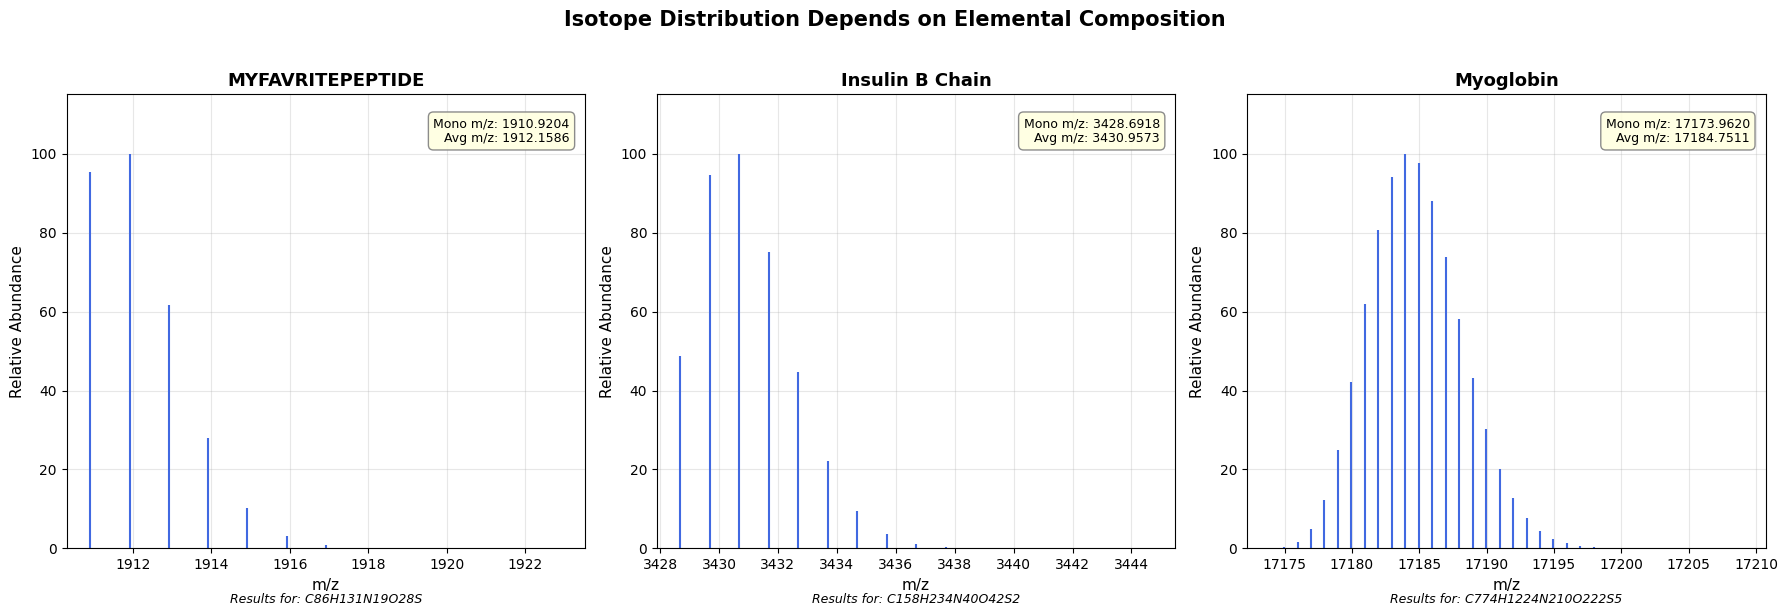

In [6]:
def plot_molecule_comparison(molecules, charge=1, resolving_power=5000):
    """Compare isotope distributions for multiple molecules side by side.

    Args:
        molecules: List of dicts with 'name' and 'input' keys.
        charge: Charge state for all molecules.
        resolving_power: Resolving power for profile display.
    """
    n = len(molecules)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, mol in zip(axes, molecules):
        composition = ic.parse_input(mol["input"])
        formula = ic.composition_to_formula(composition)
        dist = ic.calculate_isotope_distribution(composition)
        mono = ic.monoisotopic_mass(composition)
        avg = ic.average_mass(composition, dist)
        mz = ic.mz_values(mono, len(dist), charge)

        mono_mz = (mono + charge * ic.PROTON_MASS) / charge
        avg_mz = (avg + charge * ic.PROTON_MASS) / charge

        # Centroid sticks
        markerline, stemlines, baseline = ax.stem(
            mz, dist * 100, linefmt="b-", markerfmt=" ", basefmt="k-"
        )
        plt.setp(stemlines, linewidth=1.5, color="royalblue")
        plt.setp(baseline, visible=False)

        # Info box with masses
        info_text = (f"Mono m/z: {mono_mz:.4f}\n"
                     f"Avg m/z: {avg_mz:.4f}")
        ax.text(0.97, 0.95, info_text, transform=ax.transAxes,
                fontsize=9, va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow",
                          edgecolor="gray", alpha=0.9))

        ax.set_title(f"{mol['name']}", fontsize=13, fontweight="bold")
        ax.set_xlabel("m/z", fontsize=11)
        ax.set_ylabel("Relative Abundance", fontsize=11)
        ax.set_ylim(0, 115)
        ax.grid(True, alpha=0.3)

        # Formula below plot
        ax.text(0.5, -0.12, f"Results for: {formula}",
                transform=ax.transAxes, fontsize=9, ha="center",
                style="italic")

    fig.suptitle("Isotope Distribution Depends on Elemental Composition",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# Compare three molecules of increasing size
molecules = [
    {"name": "MYFAVRITEPEPTIDE", "input": "MYFAVRITEPEPTIDE"},
    {"name": "Insulin B Chain",
     "input": "FVNQHLCGSHLVEALYLVCGERGFFYTPKT"},
    {"name": "Myoglobin", "input": "C774H1224N210O222S5"},
]

plot_molecule_comparison(molecules, charge=1, resolving_power=5000)

## Algorithm and References

### Kubinyi Algorithm

The isotope distribution is calculated using the polynomial expansion method
described by Kubinyi (*Analytica Chimica Acta*, 247, 1991, 107-119). The
algorithm works by iteratively convolving the isotope abundance patterns for
each element:

1. Initialize a pattern array `[1.0]`
2. For each element with *n* atoms, convolve the current pattern with that
   element's isotope abundance vector *n* times
3. After each convolution, normalize to the maximum value and trim peaks below
   a precision threshold (10^-7)
4. The final array gives the relative abundances of each isotopic peak

For efficiency, this implementation uses binary expansion: instead of *n*
individual convolutions, the atom count is decomposed into powers of two,
requiring only ~log2(*n*) convolutions per element.

### Peak Profile Generation

Each isotopic peak is modeled as a Gaussian with full-width at half-maximum
(FWHM) determined by the resolving power:

    FWHM = m/z / R

where *R* is the resolving power. The Gaussian standard deviation is:

    sigma = FWHM / (2 * sqrt(2 * ln(2)))

### Isotope Abundances

Natural isotope abundances are from D.E. Matthews as implemented in
[IDCalc](https://github.com/maccoss/IDCalc).

### References

- Kubinyi, H. "Calculation of isotope distributions in mass spectrometry.
  A trivial solution for a non-trivial problem." *Analytica Chimica Acta*,
  247, 107-119 (1991).
- Sleno, L. and Bhardwaj, R. *J. Mass Spectrom.* 2004: 16, 183.